<a href="https://colab.research.google.com/github/ADITI9981/Deep_Learning/blob/main/Data_Augmentation(tensorflow_Flower_Data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [20]:
import tensorflow as tf

# URL for the flower photos dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# Re-download and extract the dataset
data_dir = tf.keras.utils.get_file(
    'flower_photos',
    origin=dataset_url,
    cache_dir='/tmp/.keras/datasets',  # The directory where the dataset will be stored
    untar=True  # Automatically extract the dataset
)

print("Dataset downloaded and extracted to:", data_dir)


228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Dataset downloaded and extracted to: /tmp/.keras/datasets/datasets/flower_photos


In [21]:
import os

# Check the contents of the dataset directory
print("Categories:", os.listdir(data_dir))


Categories: ['flower_photos']


In [22]:
data_dir


'/tmp/.keras/datasets/datasets/flower_photos'

In [24]:
import pathlib
data_dir=pathlib.Path(data_dir)
data_dir

PosixPath('/tmp/.keras/datasets/datasets/flower_photos')

In [31]:
# List all .jpg files in the flower categories subdirectories
jpg_files = list(data_dir.rglob('*.jpg'))

# Print the list of .jpg files
image_count=len(jpg_files)
image_count

3670

In [33]:
roses=list(data_dir.rglob('roses/*'))
roses[:5]

[PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/8524505868_236f4c94b5.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/17090993740_fcc8b60b81.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/5990626258_697f007308_n.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/16334786972_1b3e71cab8_m.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/15032112248_30c5284e54_n.jpg')]

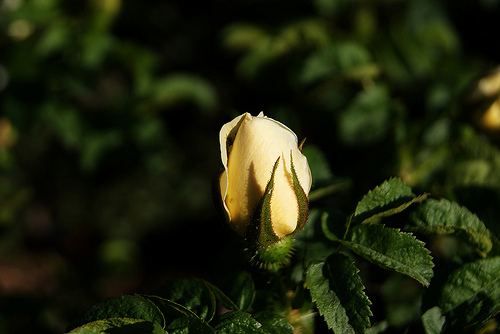

In [34]:
PIL.Image.open(str(roses[1]))

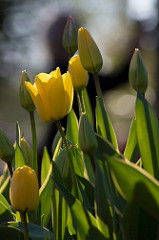

In [36]:
tulips=list(data_dir.rglob('tulips/*'))
PIL.Image.open(str(tulips[1]))

In [37]:
flower_images_dic = {
    'roses': list(data_dir.rglob('roses/*')),
    'daisy': list(data_dir.rglob('daisy/*')),
    'dandelion': list(data_dir.rglob('dandelion/*')),
    'sunflowers': list(data_dir.rglob('sunflowers/*')),
    'tulips': list(data_dir.rglob('tulips/*')),
}

In [39]:
flower_images_dic['roses']

[PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/8524505868_236f4c94b5.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/17090993740_fcc8b60b81.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/5990626258_697f007308_n.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/16334786972_1b3e71cab8_m.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/15032112248_30c5284e54_n.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/9353111163_7a89b2df35_n.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/483444865_65962cea07_m.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/7345657862_689366e79a.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets/flower_photos/flower_photos/roses/3873271620_1d9d314f01_n.jpg'),
 PosixPath('/tmp/.keras/datasets/datasets

In [40]:
flower_labels_dict={
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,
}

In [48]:
img = cv2.imread(str(flower_images_dic['roses'][0]))
img.shape

(281, 500, 3)

In [49]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [50]:
x,y=[],[]

for flower_name,images in flower_images_dic.items():
    for image in images:
        img=cv2.imread(str(image))
        resized_img=cv2.resize(img,(180,180))
        x.append(resized_img)
        y.append(flower_labels_dict[flower_name])

In [52]:
x[:5]

[array([[[177, 181, 175],
         [182, 187, 180],
         [184, 189, 180],
         ...,
         [162, 170, 163],
         [155, 164, 157],
         [150, 159, 154]],
 
        [[187, 191, 185],
         [184, 188, 181],
         [187, 192, 183],
         ...,
         [168, 176, 169],
         [163, 171, 164],
         [157, 164, 159]],
 
        [[190, 194, 189],
         [191, 193, 187],
         [189, 194, 184],
         ...,
         [169, 178, 171],
         [165, 175, 168],
         [162, 170, 165]],
 
        ...,
 
        [[200, 203, 197],
         [206, 208, 202],
         [204, 206, 200],
         ...,
         [173, 178, 175],
         [172, 187, 182],
         [170, 183, 175]],
 
        [[201, 203, 197],
         [201, 203, 197],
         [200, 202, 196],
         ...,
         [180, 199, 190],
         [162, 175, 168],
         [179, 193, 183]],
 
        [[201, 203, 197],
         [211, 214, 208],
         [207, 214, 205],
         ...,
         [171, 189, 178],
  

In [53]:
x=np.array(x)
y=np.array(y)

In [54]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0)

In [55]:
len(x_train)

2752

In [56]:
len(x_test)

918

In [57]:
x_train_scaled=x_train/255
x_test_scaled=x_test/255

In [61]:
num_classes=5
model = Sequential([
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

model.compile(optimizer='adam',
               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
               metrics=['accuracy'])

model.fit(x_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.3765 - loss: 1.5020
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6224 - loss: 0.9563
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7003 - loss: 0.7964
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7833 - loss: 0.6150
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8821 - loss: 0.3589
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9187 - loss: 0.2429
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9594 - loss: 0.1440
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9777 - loss: 0.0797
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9905 - loss: 0.0387
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9944 - loss: 0.0292
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9805 - loss: 0.0723
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy:

In [62]:
model.evaluate(x_train_scaled,y_train)

86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9998 - loss: 0.0010


[0.0016125960974022746, 0.9996366500854492]

In [63]:
model.evaluate(x_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6399 - loss: 2.6992


[2.773359775543213, 0.6241829991340637]

In [64]:
predictions=model.predict(x_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


array([[  0.5658313 ,  -3.17701   ,   6.032658  ,  -1.8177494 ,
          3.857322  ],
       [ 30.668684  , -15.951914  , -10.454546  , -16.646238  ,
         18.178984  ],
       [  4.447513  ,  -0.91029   ,   6.021519  ,  -2.0624774 ,
         -8.373533  ],
       ...,
       [ -8.078632  ,  -6.1440587 ,   5.0055327 ,   4.4164166 ,
         -2.0097032 ],
       [ 11.741219  ,  -6.2004848 ,  -4.4468837 ,  -7.7180037 ,
          7.6484833 ],
       [  0.96733135,  -9.891994  ,  -2.6506498 ,  11.95888   ,
          3.8122597 ]], dtype=float32)

In [66]:
score=tf.nn.softmax(predictions[0])
score

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([3.77776590e-03, 8.94828408e-05, 8.94227028e-01, 3.48384725e-04,
       1.01557344e-01], dtype=float32)>

In [76]:
np.argmax(score)

np.int64(2)

In [77]:
y_test[0]

np.int64(1)

In [81]:
data_augmentation=keras.Sequential([
    layers.RandomZoom(0.1),
    layers.RandomFlip("horizontal",input_shape=(img_height,img_width,3)),
    layers.RandomRotation(0.1),
])

NameError: name 'img_height' is not defined

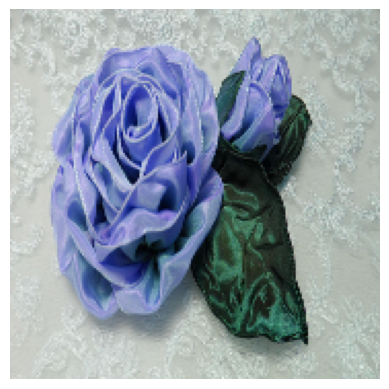

In [79]:
plt.axis('off')
plt.imshow(x[0])

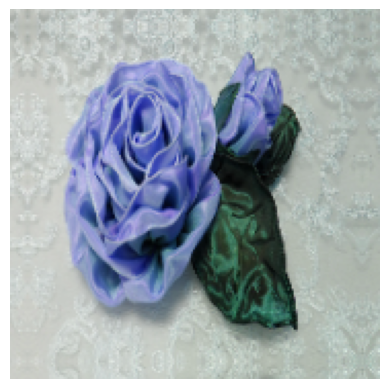

In [80]:
plt.axis('off')
plt.imshow(data_augmentation(x)[0].numpy().astype("uint8"))

In [82]:
num_classes=5
model = Sequential([
    data_augmentation,
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

model.compile(optimizer='adam',
               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
               metrics=['accuracy'])

model.fit(x_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.2925 - loss: 1.6643
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5735 - loss: 1.0633
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6447 - loss: 0.9184
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6832 - loss: 0.8274
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7127 - loss: 0.7525
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7581 - loss: 0.6581
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8019 - loss: 0.5440
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8347 - loss: 0.4745
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8410 - loss: 0.4116
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8444 - loss: 0.4508
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8761 - loss: 0.3616
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy:

In [83]:
model.evaluate(x_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7141 - loss: 1.4915


[1.522386908531189, 0.7124183177947998]